In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import numpy as np

## Get Data (see more detail in persistant_infections.ipynb)

In [2]:
overview = pd.read_csv('bronko_results/bronko_overview.tsv', delimiter='\t')
high_quality = overview[(overview['depth_coverage'] > 3000) & (overview['breadth_coverage'] > 0.95)]

## get metadata
meta = pd.read_excel('mmc3 (1).xlsx')
files = glob.glob("ena_*.tsv")
accs = pd.concat((pd.read_csv(f, delimiter='\t') for f in files), ignore_index=True)
accs["COG-ID"] = accs["description"].str.extract(r"COG-UK/([^/]+)/")
merged = meta.merge(accs, on='COG-ID', how='inner')

high_quality['accession'] = high_quality['filename'].str.extract(r"([^/]+)(?=\_1.fastq)")
high_quality_with_meta = high_quality.merge(merged, on="accession", how="left")

final_data = high_quality_with_meta[high_quality_with_meta["person id"].map(high_quality_with_meta["person id"].value_counts()) > 1]
# final_data = final_data[final_data['accession'] != 'ERR10119582']

print("Number of individuals:", len(final_data['person id'].value_counts()))
print("Number of samples:", len(final_data['person id']))

Number of individuals: 58
Number of samples: 125


/tmp/ipykernel_3398503/2642779548.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_quality['accession'] = high_quality['filename'].str.extract(r"([^/]+)(?=\_1.fastq)")


## Plot for figure 3

/tmp/ipykernel_3398503/629595228.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["",0,5,10,15,20])


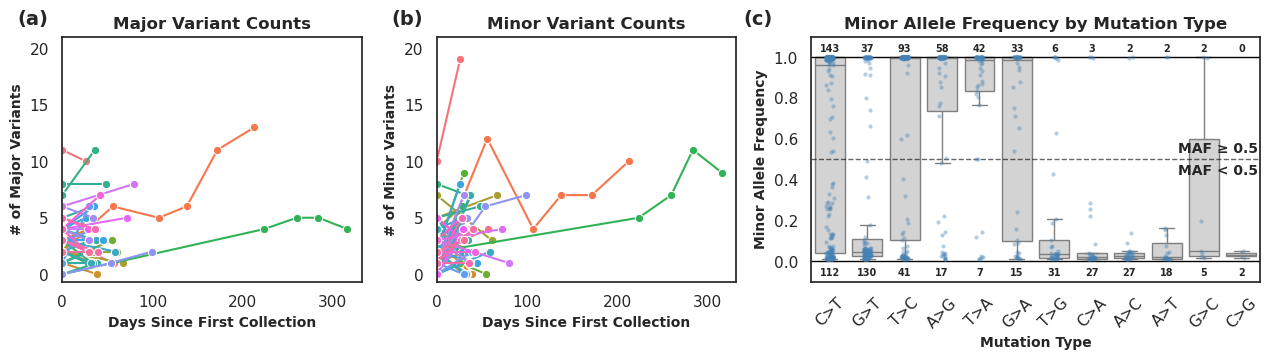

In [25]:
from pathlib import Path

sns.set_theme(style="white")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

sns.set_theme(style="white")

def mutation_spectrum_af_plot_split(final_data, vcf_dir="bronko_results", min_af=0.01, ax=None):
    accessions = final_data["accession"].unique().tolist()
    records = []

    for acc in accessions:
        vcf_path = Path(vcf_dir) / f"{acc}_1.vcf"
        if not vcf_path.exists():
            continue
        with open(vcf_path) as f:
            lines = [l.strip() for l in f if not l.startswith("#")]
        if not lines:
            continue

        df = pd.DataFrame([l.split("\t") for l in lines],
                          columns=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO"])
        df["accession"] = acc
        df["person"] = final_data.loc[final_data["accession"] == acc, "person id"].iloc[0]
        df["AF"] = df["INFO"].str.extract(r"AF=([\d\.eE-]+)").astype(float)
        df["SOR"] = df["INFO"].str.extract(r"SOR=([\d\.eE-]+)").astype(float)
        df["Depth"] = df["INFO"].str.extract(r"DP=([\d\.eE-]+)").astype(float)
        df = df[df["AF"] > min_af]
        df = df[(df["SOR"] >= 0) & (df["SOR"] <= 6.0)]
        df["mutation"] = df["REF"] + ">" + df["ALT"]
        records.append(df[["mutation", "AF", "accession", "POS", "CHROM", "SOR", "person"]])

    if not records:
        print("No variants found for selected samples.")
        return None

    all_variants = pd.concat(records, ignore_index=True)
    all_variants = all_variants[all_variants["SOR"] != 12.0]

    mut_counts = (
        all_variants["mutation"].value_counts().reset_index()
        .rename(columns={"index": "mutation"})
    )
    order = mut_counts.sort_values("count", ascending=False)["mutation"].tolist()

    sns.boxplot(
        data=all_variants, x="mutation", y="AF",
        order=order, fliersize=0, color="lightgray", ax=ax
    )
    sns.stripplot(
        data=all_variants, x="mutation", y="AF",
        order=order, jitter=True, size=3, alpha=0.4,
        color="steelblue", ax=ax
    )

    ax.axhline(0.5, color="black", lw=1, linestyle="--", alpha=0.6)
    ax.text(9.3, 0.52, "MAF ≥ 0.5", fontsize=10, fontweight="bold", va="bottom")
    ax.text(9.3, 0.48, "MAF < 0.5", fontsize=10, fontweight="bold", va="top")

    major_variants = all_variants[all_variants["AF"] >= 0.5]
    minor_variants = all_variants[all_variants["AF"] < 0.5]
    order_counts = lambda v: v.groupby("mutation")["AF"].count().reindex(order)

    for i, count in enumerate(order_counts(major_variants)):
        ax.text(i, 1.02, str(int(count)) if not pd.isna(count) else "0",
                ha="center", va="bottom", fontsize=7, fontweight="bold")
    for i, count in enumerate(order_counts(minor_variants)):
        ax.text(i, -0.08, str(int(count)) if not pd.isna(count) else "0",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax.set_title("Minor Allele Frequency by Mutation Type", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mutation Type", fontsize=10, fontweight="bold")
    ax.set_ylabel("Minor Allele Frequency", fontsize=10, fontweight="bold")
    ax.set_ylim(-0.1, 1.1)
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(1, color='black', lw=1)
    ax.text(-0.15, 1.05, "(c)", fontsize=14, fontweight="bold", transform=ax.transAxes)

    return all_variants


def plot_major_variants(ax, variants, final_data):
    major_variants = variants[variants['AF'] >= 0.5].groupby('accession').count()
    major_variants = major_variants.merge(final_data, on=['accession'], how="outer")
    major_variants['mutation'] = major_variants['mutation'].fillna(0)
    
    df = major_variants.sort_values(["person id", "sequence collection date"])
    df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])
    df["timepoint"] = df.groupby("person id")["sequence collection date"].transform(lambda x: (x - x.min()).dt.days)

    sns.lineplot(data=df, x="timepoint", y="mutation", hue="person id", marker="o", legend=False, ax=ax)
    ax.set_xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
    ax.set_ylabel("# of Major Variants", fontweight='bold', fontsize=10)
    ax.set_title("Major Variant Counts", fontweight='bold', fontsize=12)
    ax.set_xlim(left=0)
    ax.set_ylim(top=21)
    ax.set_yticklabels(["",0,5,10,15,20])
    ax.text(-0.15, 1.05, "(a)", fontsize=14, fontweight="bold", transform=ax.transAxes)

    return df

def plot_minor_variants(ax, variants, final_data):
    
    all_accs = final_data["accession"]

    # count minor variants per accession (missing = 0)
    minor_variants = (
        variants[variants['AF'] < 0.5]
        .groupby("accession")
        .size()
        .reindex(all_accs, fill_value=0)       # ensures all accessions present
        .reset_index(name="mutation")
    )
    minor_variants = minor_variants.merge(final_data, on=['accession'], how="left")
    minor_variants['mutation'] = minor_variants['mutation'].fillna(0)

    df = minor_variants.sort_values(["person id", "sequence collection date"])
    df["sequence collection date"] = pd.to_datetime(df["sequence collection date"])
    df["timepoint"] = df.groupby("person id")["sequence collection date"].transform(lambda x: (x - x.min()).dt.days)

    sns.lineplot(data=df, x="timepoint", y="mutation", hue="person id", marker="o", legend=False, ax=ax)
    ax.set_xlabel("Days Since First Collection", fontweight='bold', fontsize=10)
    ax.set_ylabel("# of Minor Variants", fontweight='bold', fontsize=10)
    ax.set_title("Minor Variant Counts", fontweight='bold', fontsize=12)
    ax.set_xlim(left=0)
    ax.text(-0.15, 1.05, "(b)", fontsize=14, fontweight="bold", transform=ax.transAxes)
    
    return df


fig, axes = plt.subplots(1, 3, figsize=(13, 4), width_ratios=(2,2,3))
ax1, ax2, ax3 = axes
ax1.sharey(ax2)

# Panel a (mutation spectrum)
all_variants = mutation_spectrum_af_plot_split(final_data, ax=ax3)

# Panels b & c (major / minor)
df1 = plot_major_variants(ax1, all_variants, final_data)
df2 = plot_minor_variants(ax2, all_variants, final_data)

plt.subplots_adjust(top=0.9, wspace=0.3)  # add headroom + spacing between panels
plt.tight_layout(rect=[0, 0, 1, 0.95])     # preserve the top margin
plt.savefig("../figures/Fig3.pdf", bbox_inches='tight')  # Best for LaTeX
plt.savefig("../figures/Fig3.png", dpi=600, bbox_inches='tight')  # High-res PNG
plt.show()


In [10]:
print("Total variants:", len(all_variants))
print("Total major variants:", len(all_variants[all_variants['AF'] >= 0.5]))
print("Total minor variants:", len(all_variants[all_variants['AF'] < 0.5]))

Total variants: 853
Total major variants: 421
Total minor variants: 432


In [17]:
counts = (
    all_variants.groupby(["person", "mutation", "POS"])["accession"]
    .nunique()
    .reset_index(name="n_accessions")
)

# merge back to annotate each row
annotated = all_variants.merge(counts, on=["person", "mutation", "POS"])

# classify
annotated["is_persistent"] = annotated["n_accessions"] >= 2
annotated["is_unique"] = annotated["n_accessions"] == 1

# split major/minor
annotated["is_major"] = annotated["AF"] >= 0.5
annotated["is_minor"] = annotated["AF"] < 0.5

# summarize per person
summary = annotated.groupby("person").apply(
    lambda x: pd.Series({
        "persistent_major": (x.is_persistent & x.is_major).sum(),
        "persistent_minor": (x.is_persistent & x.is_minor).sum(),
        "unique_major":     (x.is_unique & x.is_major).sum(),
        "unique_minor":     (x.is_unique & x.is_minor).sum(),
    })
)

summary.reset_index()

/tmp/ipykernel_3398503/4221110883.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = annotated.groupby("person").apply(


,person,persistent_major,persistent_minor,unique_major,unique_minor
0,p192,2,0,2,6
1,p20,20,8,1,21
2,p286,0,0,3,8
3,p288,31,13,12,28
4,p290,6,2,1,6
5,p303,2,0,1,6
6,p306,6,0,0,5
7,p320,0,0,1,3
8,p321,6,0,0,2
9,p322,2,4,1,2


In [20]:
summary.reset_index().sum(axis=0)

person              p192p20p286p288p290p303p306p320p321p322p336p33...
persistent_major                                                  271
persistent_minor                                                   58
unique_major                                                      150
unique_minor                                                      374
dtype: object

In [21]:
271 + 58 + 150 + 374

853